# Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Reading the dataset

In [2]:
customer_data = pd.read_csv('D:\Churn_Modelling.csv')

# Droping the ineffective columns
dataset = customer_data.drop(['RowNumber', 'CustomerId', 'Surname'], axis = 1)

dataset

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


# Exploratory Data Analysis

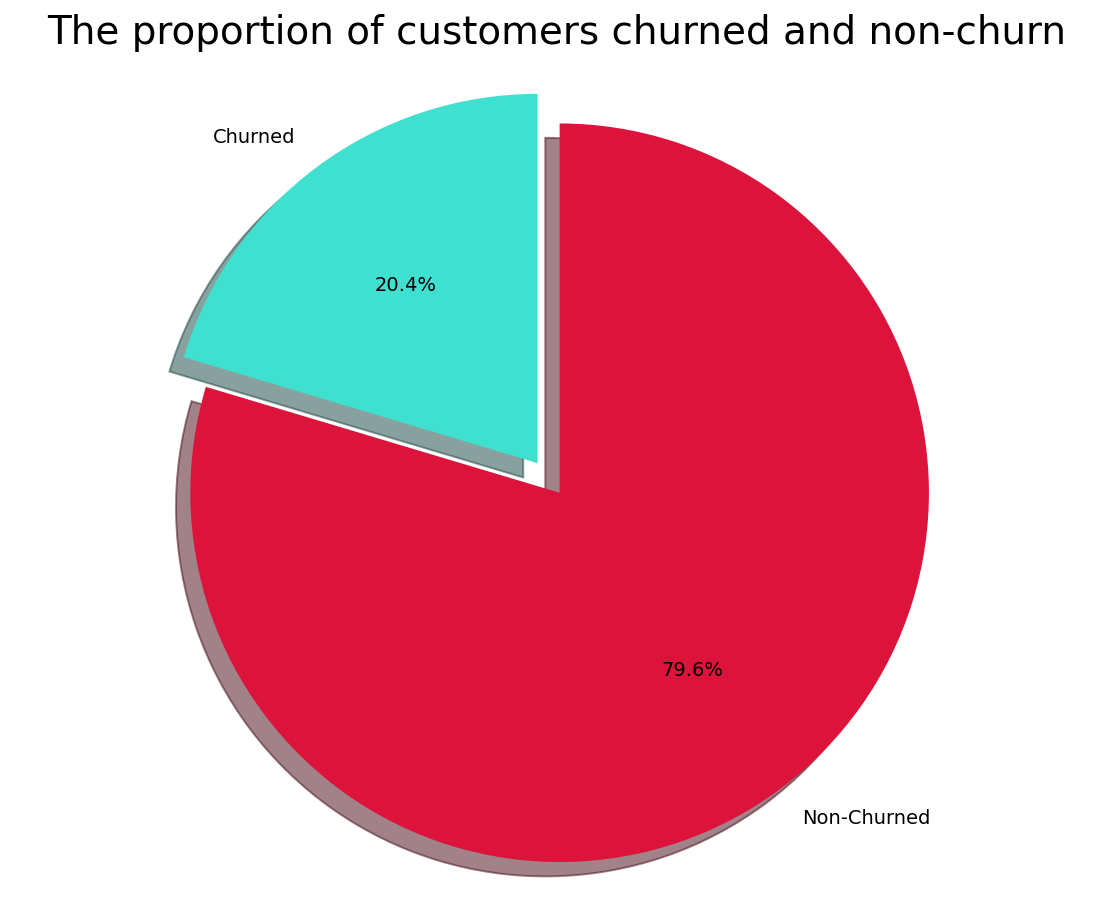

In [ ]:
labels = 'Churned', 'Non-Churned'
sizes = [dataset.Exited[dataset['Exited'] == 1].count(), dataset.Exited[dataset['Exited'] == 0].count()]
colors = ["turquoise", "crimson"]
explode = (0, 0.1)
fig1, ax1 = plt.subplots(figsize = (10, 8), dpi = 140)
ax1.pie(sizes, explode = explode, labels = labels, colors = colors, autopct = '%1.1f%%', shadow = True, startangle = 90)
ax1.axis('equal')
plt.title("The proportion of customers churned and non-churn", size = 20)
plt.savefig('Pieplot.png')
plt.show()

In [4]:
non_churn = dataset[dataset['Exited'] == 0]['Exited'].count()
churn = dataset[dataset['Exited'] == 1]['Exited'].count()
print("non_churn: ", non_churn, "\nchurn: ", churn)

non_churn:  7963 
churn:  2037


# Distribution of the categorical variables

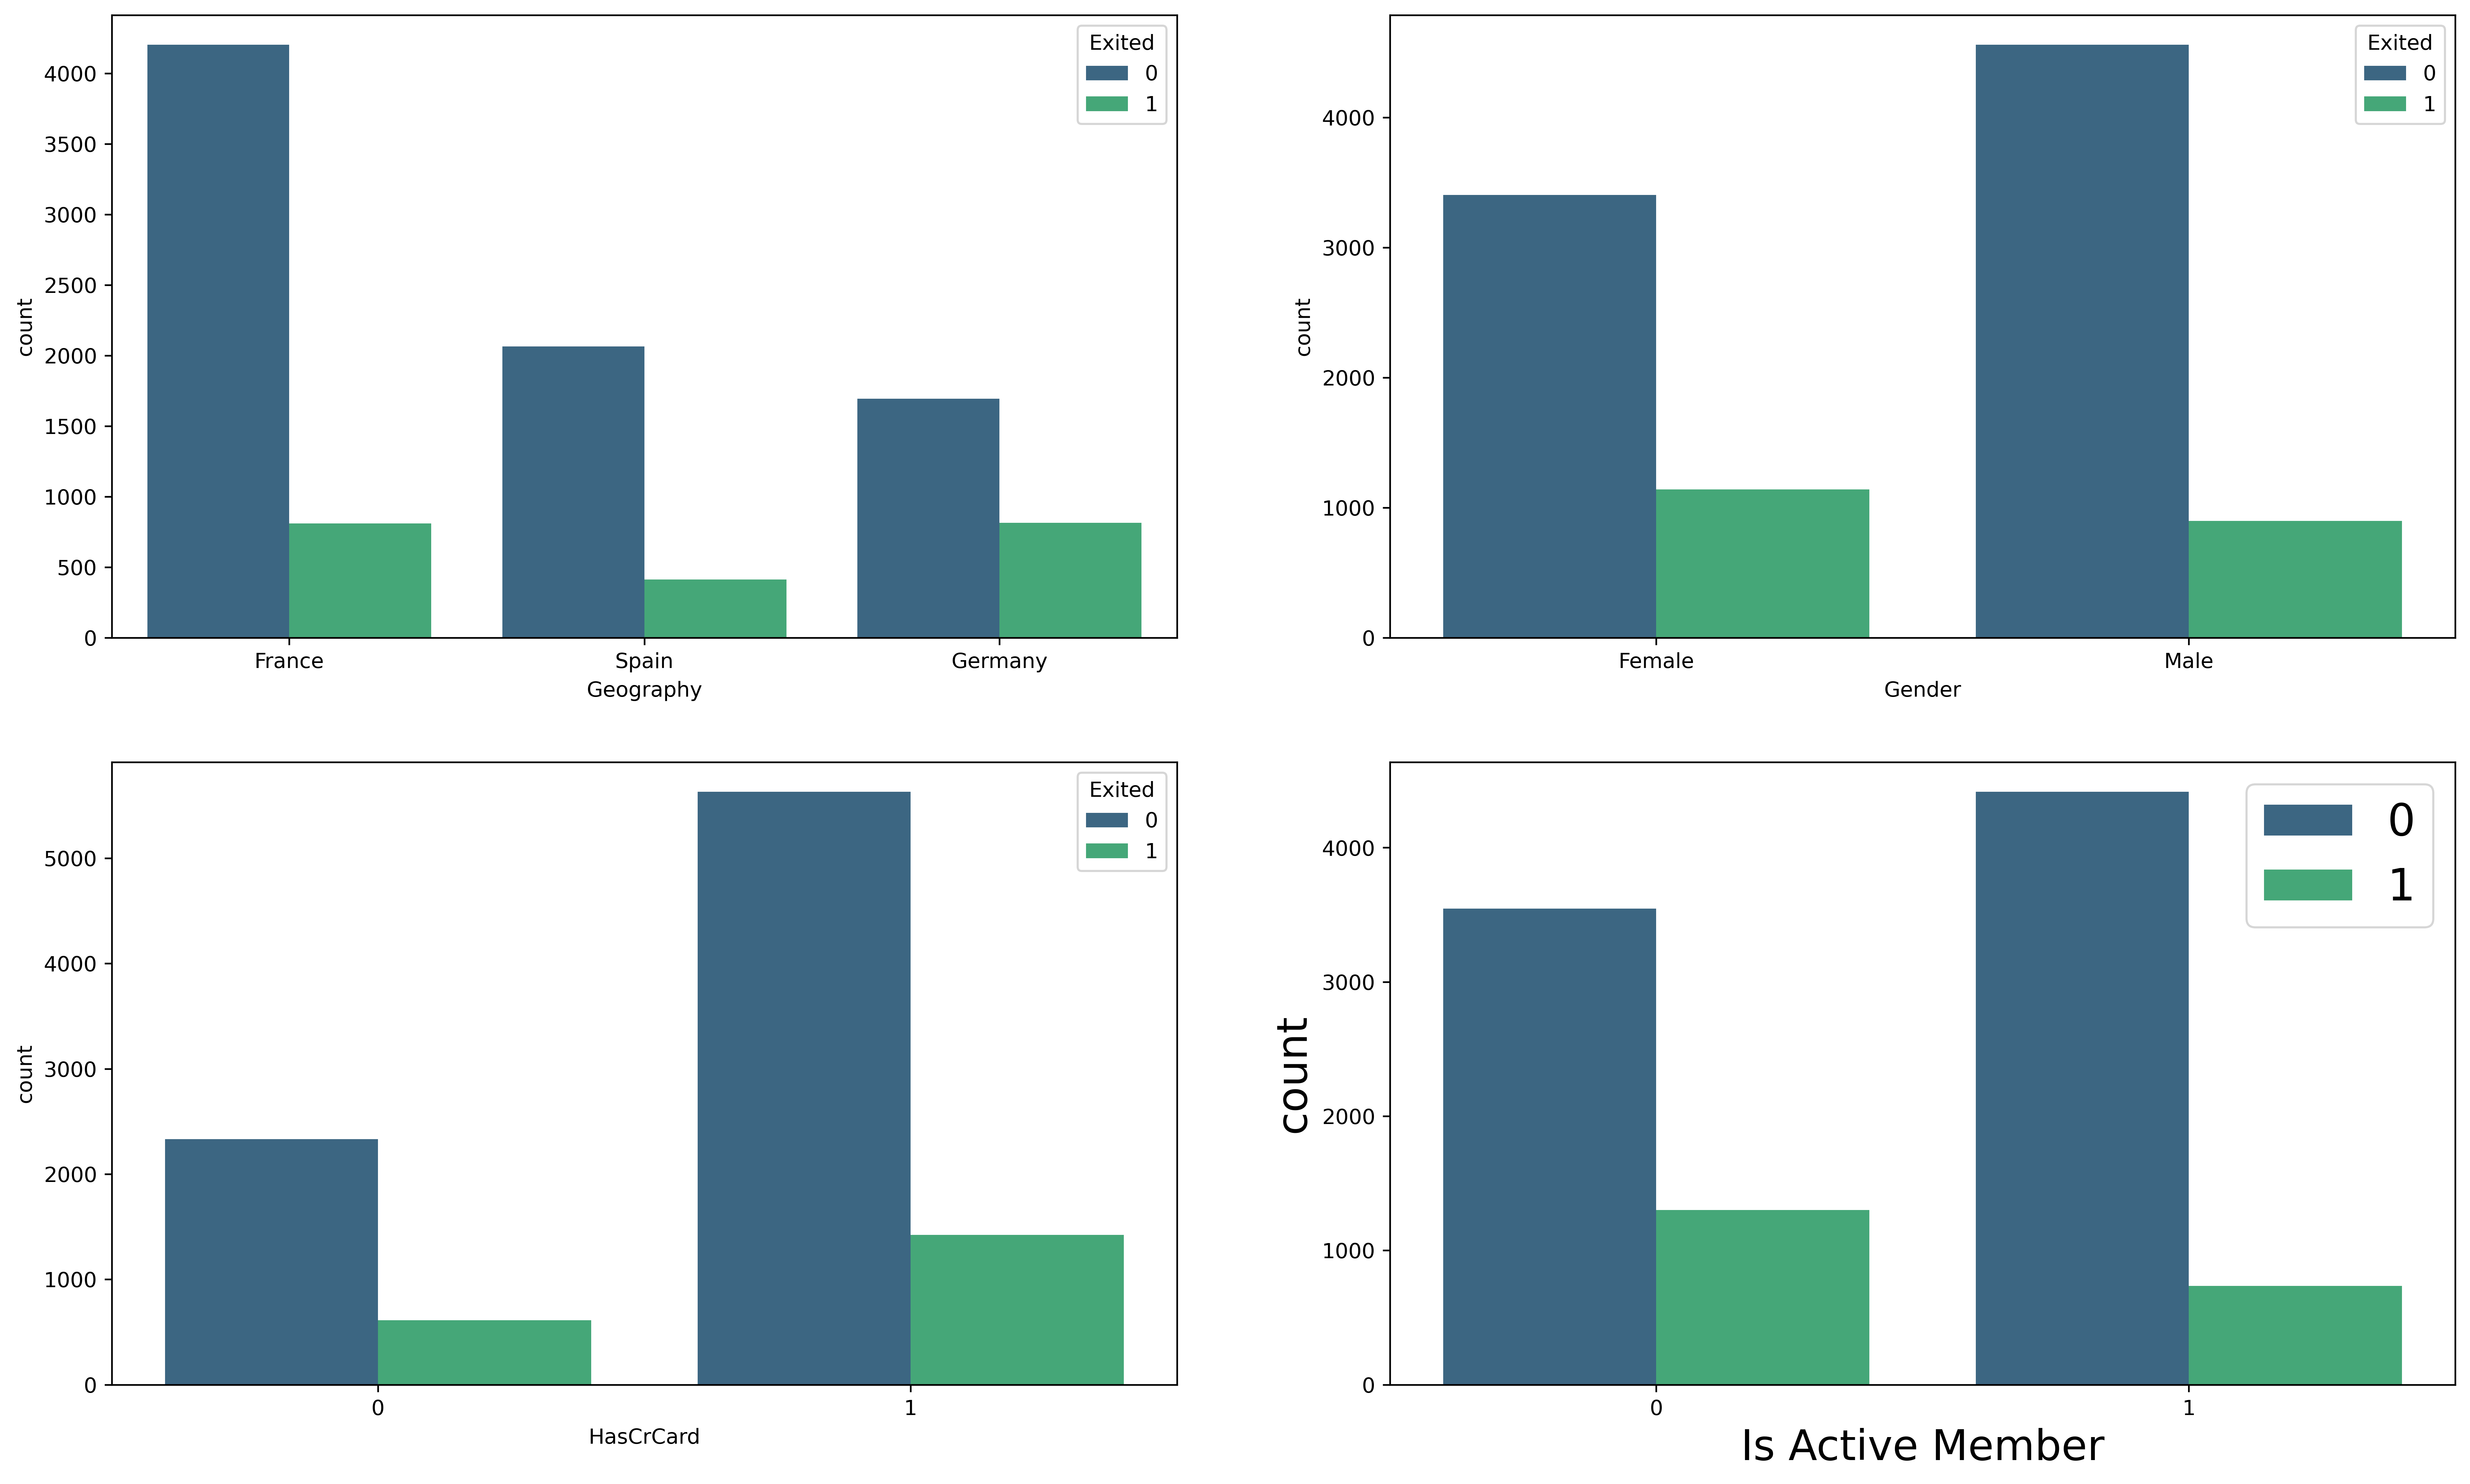

In [ ]:
fig, axarr = plt.subplots(2, 2, figsize = (20, 12), dpi = 480)

sns.countplot(x = 'Geography', hue = 'Exited', data = dataset, ax = axarr[0][0], palette = "viridis" )
plt.ylabel('count', fontsize = 20, color = 'black')
plt.xlabel('Geography', fontsize = 20, color = 'black')

sns.countplot(x = 'Gender', hue = 'Exited', data = dataset, ax = axarr[0][1], palette = "viridis")
plt.ylabel('count', fontsize = 20, color = 'black')
plt.xlabel('Gender', fontsize = 20, color = 'black')

sns.countplot(x = 'HasCrCard', hue = 'Exited', data = dataset, ax = axarr[1][0], palette = "viridis")
plt.ylabel('count', fontsize = 20, color = 'black')
plt.xlabel('Has Credit Card', fontsize = 20, color = 'black')

sns.countplot(x = 'IsActiveMember', hue = 'Exited', data = dataset, ax = axarr[1][1], palette = 'viridis')
plt.ylabel('count', fontsize = 20, color = 'black')
plt.xlabel('Is Active Member', fontsize = 20, color = 'black')

plt.legend(fontsize = 20)
plt.rc('legend', fontsize = 21)
plt.legend()
plt.savefig('CategoricalVariable.png')

# Distribution of the continuous variables

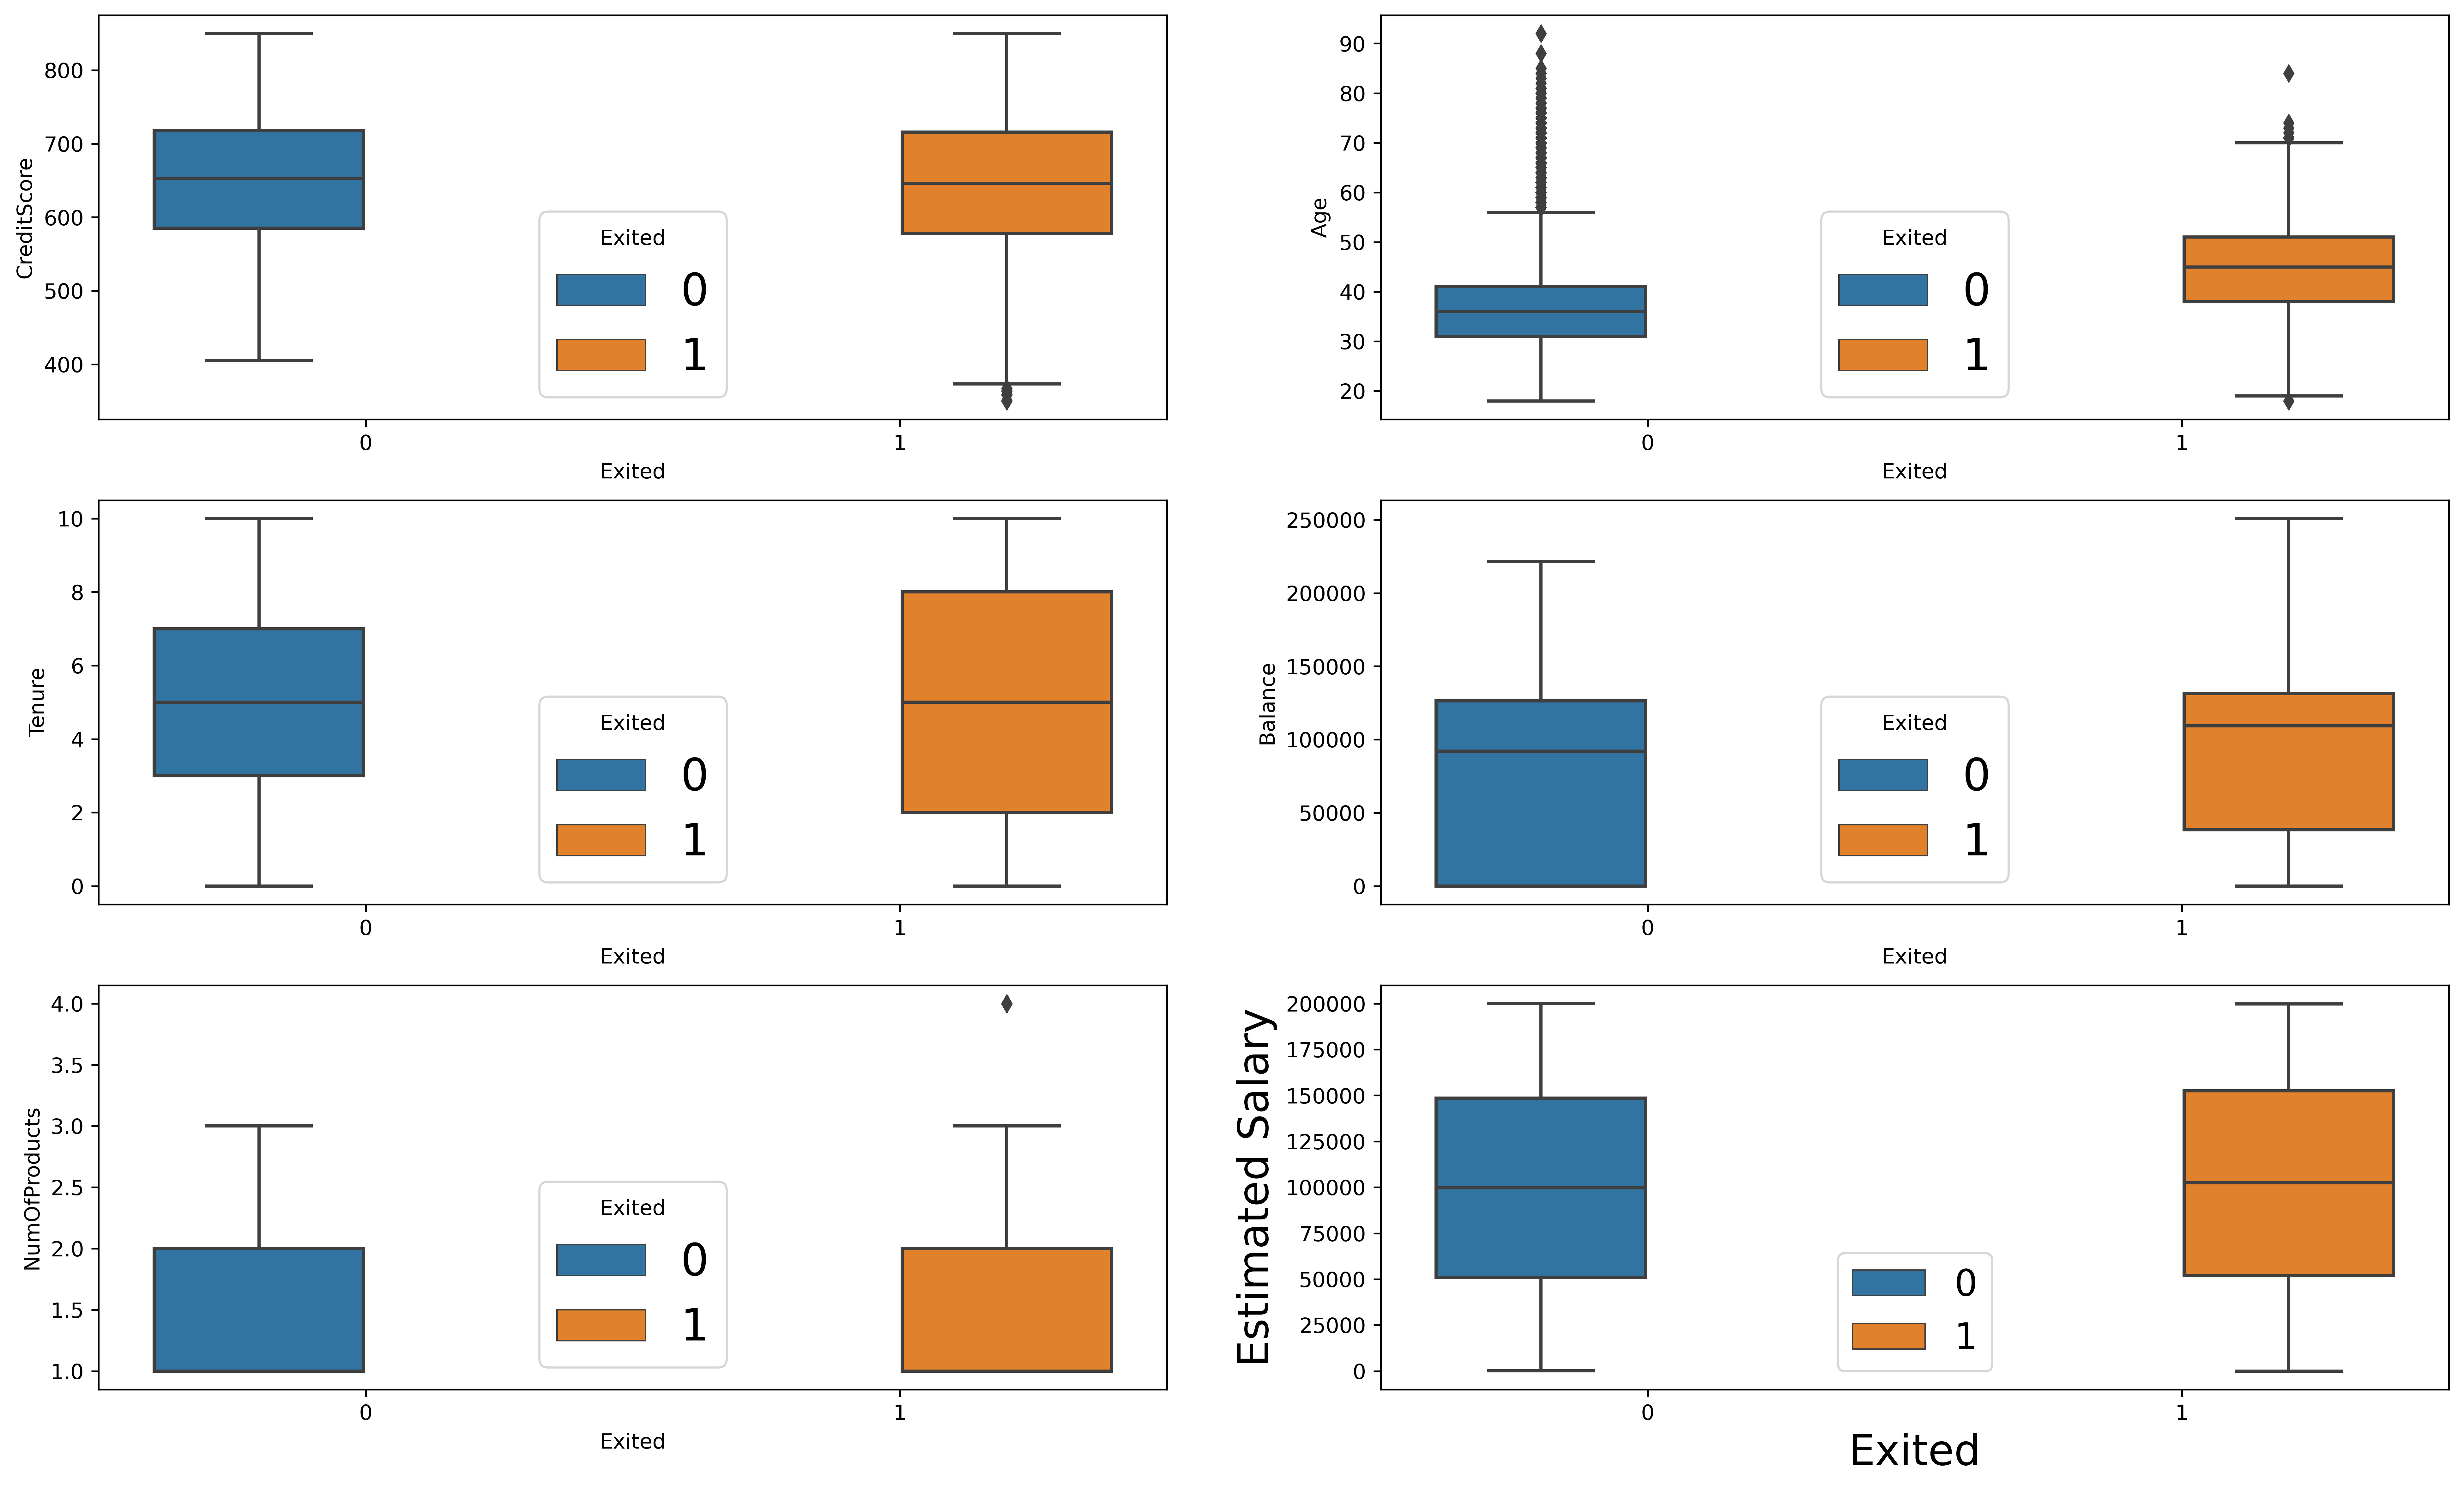

In [6]:
fig, axarr = plt.subplots(3, 2, figsize = (20, 12), dpi = 480)
sns.boxplot(y = 'CreditScore', x = 'Exited', hue = 'Exited', data = dataset, ax = axarr[0][0])
sns.boxplot(y = 'Age', x = 'Exited', hue = 'Exited', data = dataset, ax = axarr[0][1])
sns.boxplot(y = 'Tenure', x = 'Exited', hue = 'Exited', data = dataset, ax = axarr[1][0])
sns.boxplot(y = 'Balance', x = 'Exited', hue = 'Exited', data = dataset, ax = axarr[1][1])
sns.boxplot(y = 'NumOfProducts', x = 'Exited', hue = 'Exited', data = dataset, ax = axarr[2][0])
sns.boxplot(y = 'EstimatedSalary', x = 'Exited', hue = 'Exited', data = dataset, ax = axarr[2][1])

plt.xlabel('Exited', fontsize = 20, color = 'black')
plt.ylabel('Estimated Salary', fontsize = 20, color = 'black')
plt.legend(fontsize = "xx-large")
plt.savefig('ContinuousVariables.png')

# Detecting Outliers

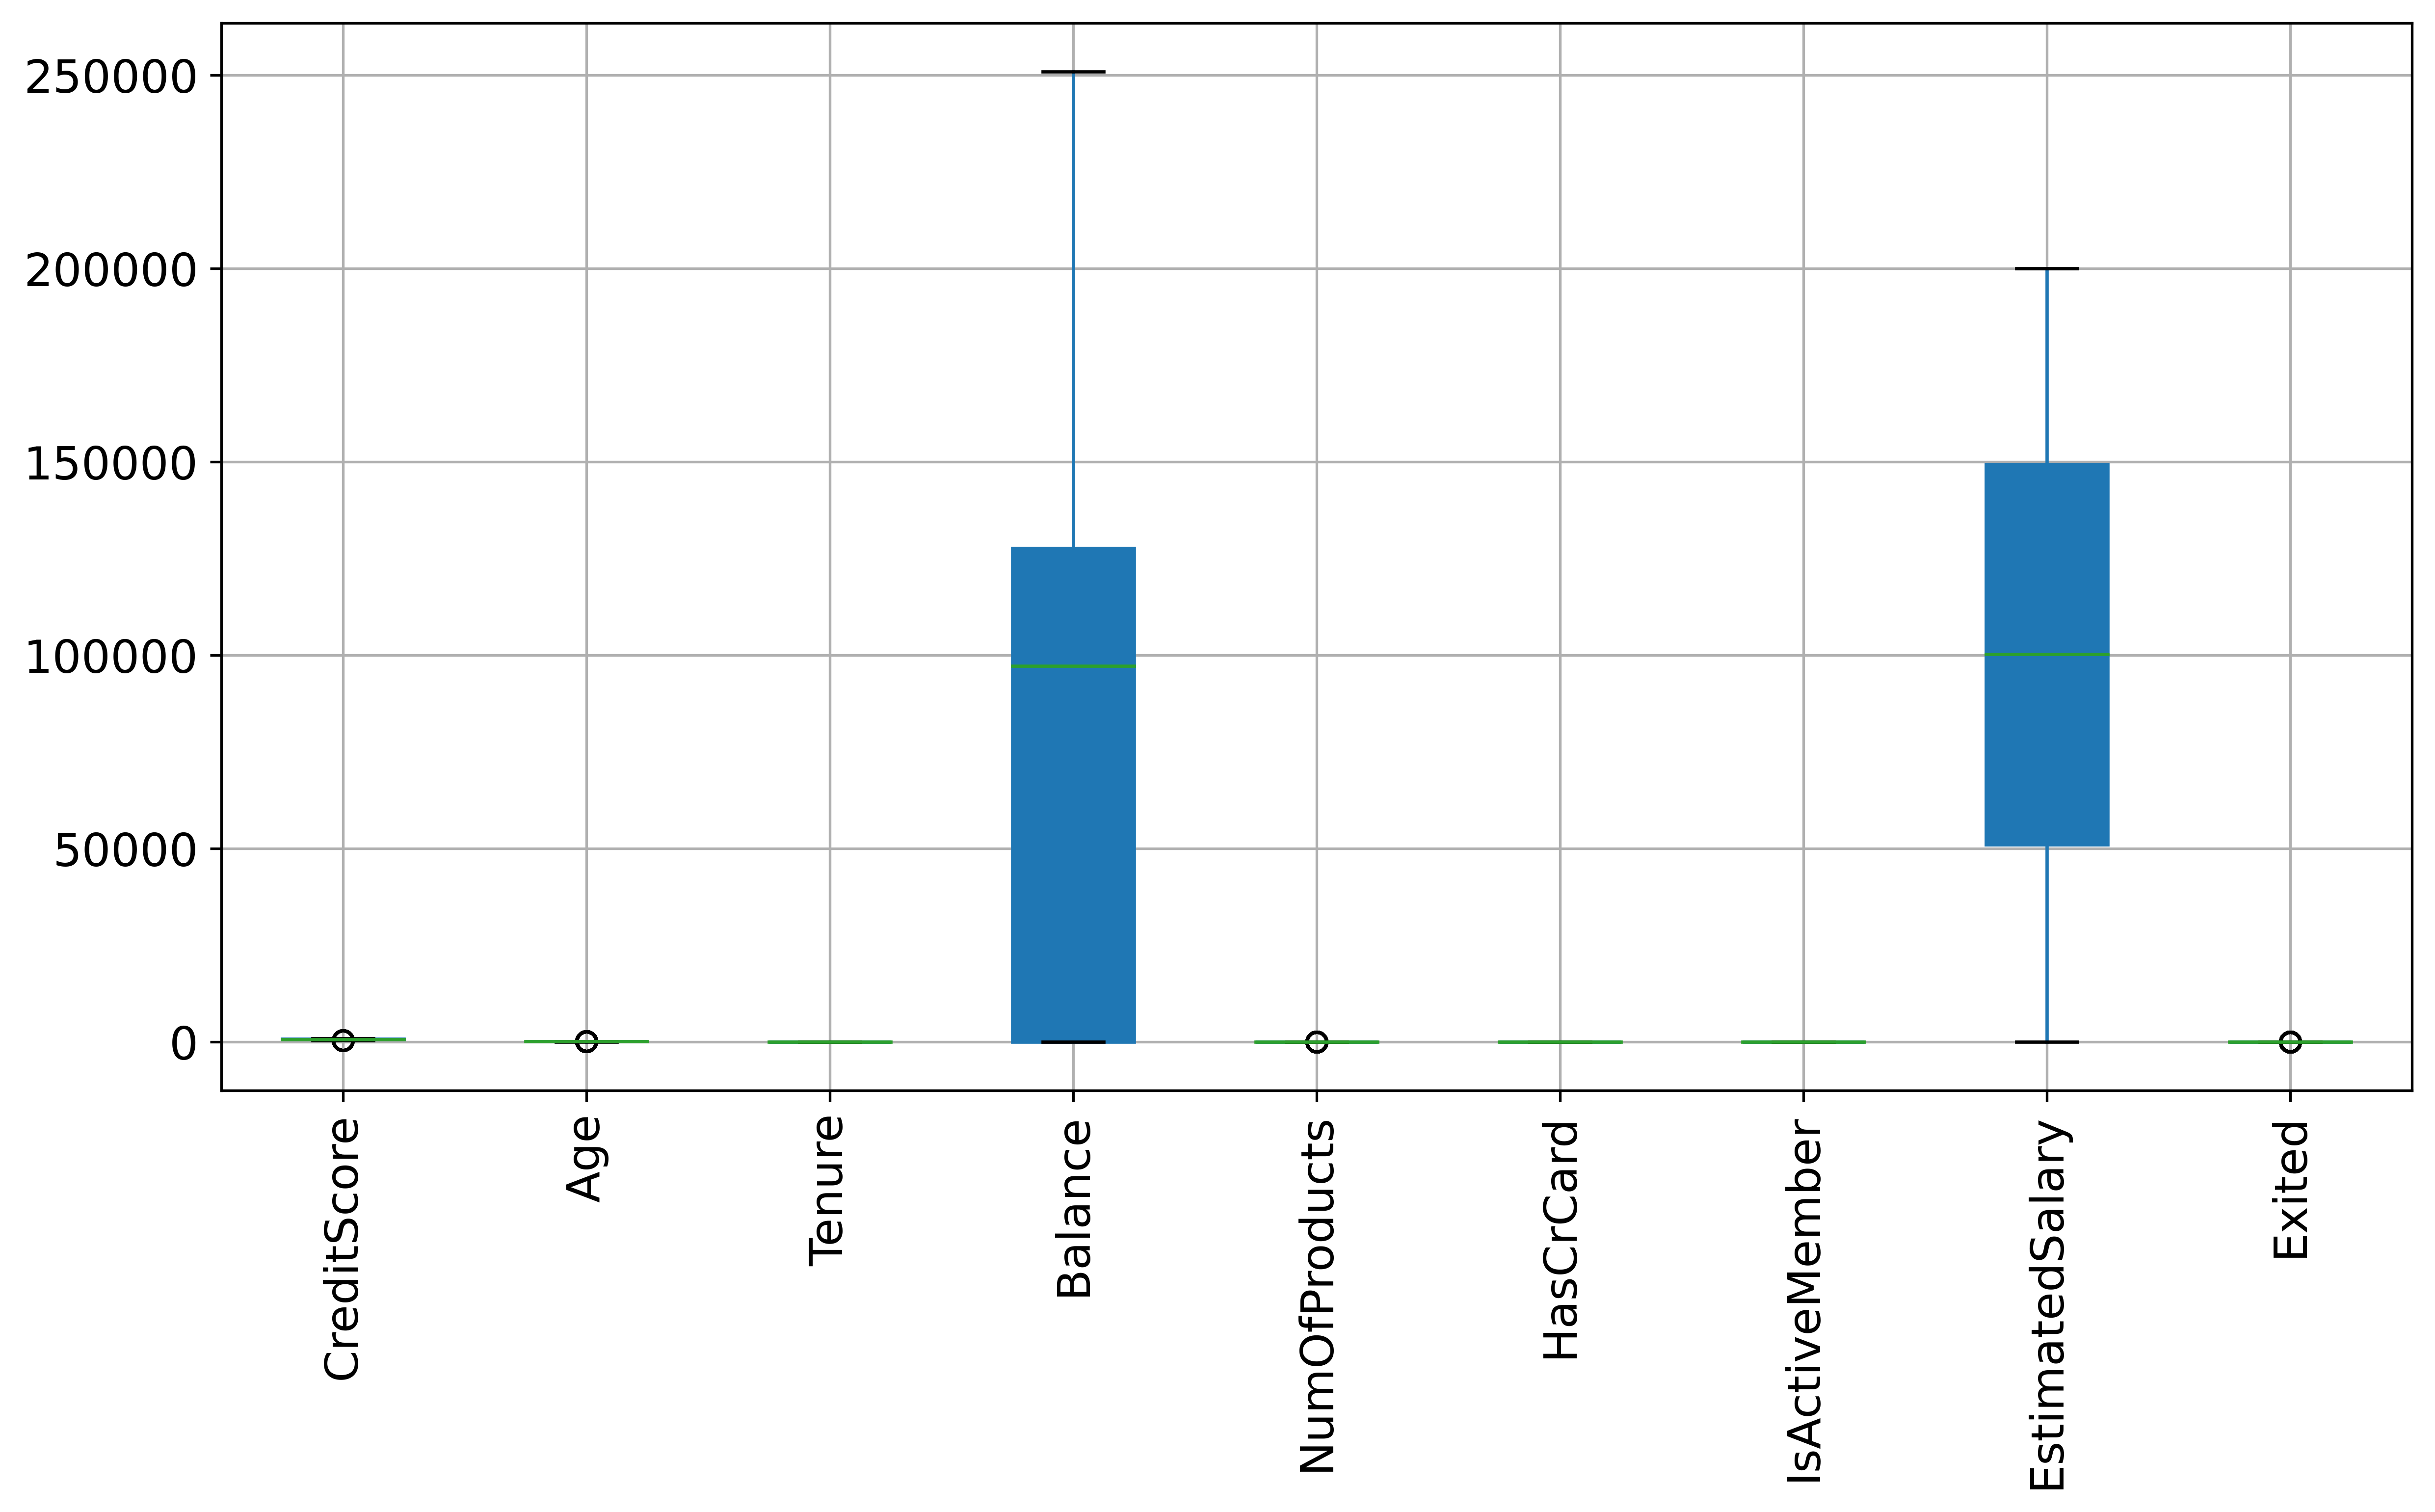

In [7]:
plt.figure(figsize = (12, 6), dpi = 480)
bplot = dataset.boxplot(patch_artist = True, fontsize = 14)
plt.xticks(rotation = 90)
plt.savefig('DetectingOutliers.png')
plt.show()

# Checking Correlation

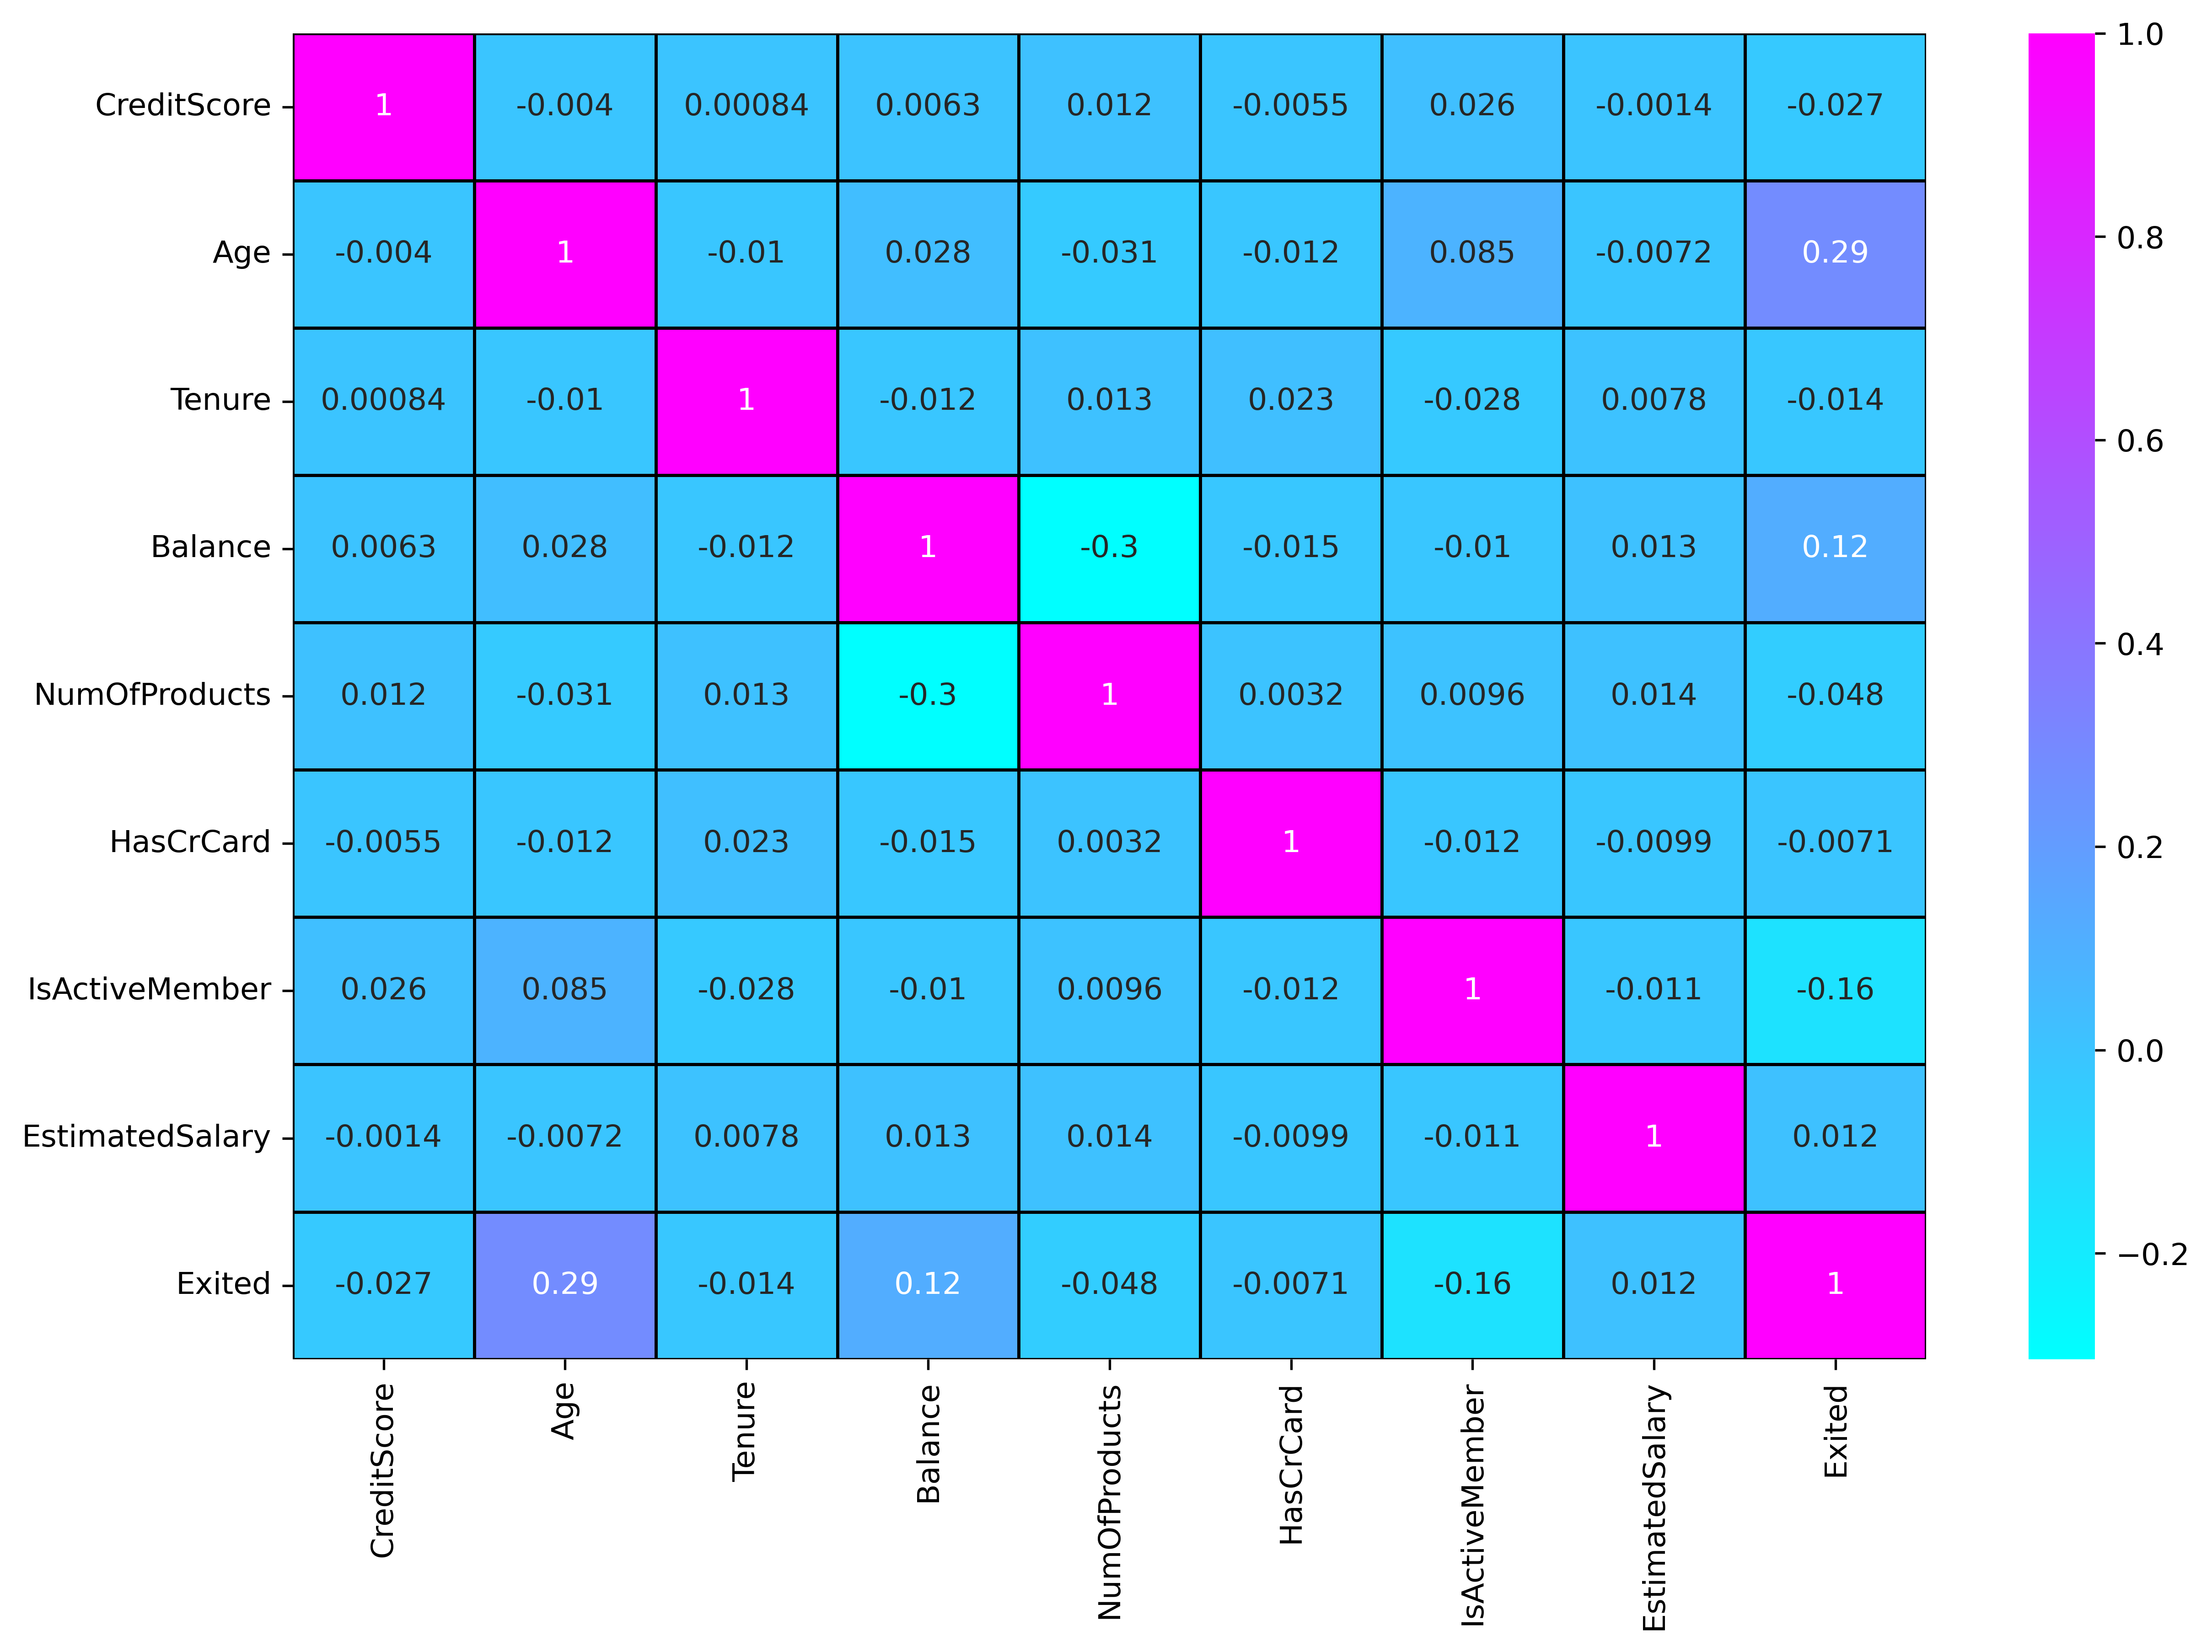

In [8]:
plt.figure(figsize = (12, 8), dpi = 480)
sns.heatmap(dataset.corr(), annot = True, cmap = "cool", linewidths = 1, linecolor = 'black')
plt.savefig('Correlation.png')
plt.show()

In [9]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Converting inputs to numeric values
encoder = LabelEncoder()
dataset["Geography"] = encoder.fit_transform(dataset["Geography"])
dataset["Gender"] = encoder.fit_transform(dataset["Gender"])

# Encoding categorical data
dataset = dataset.drop(['Geography', 'Gender'], axis = 1)
Geography = pd.get_dummies(customer_data.Geography, drop_first = True)
Gender = pd.get_dummies(customer_data.Gender).iloc[:, 0:]

# Data merging
dataset = pd.concat([dataset, Geography, Gender], axis = 1)
dataset.shape

(10000, 13)

In [10]:
# Data inputs
X = dataset.drop(['Exited'], axis = 1)
m = X

# Feature Scaling
sc = StandardScaler()
X = sc.fit_transform(X)

X = pd.DataFrame(X)
X.columns = m.columns

# Data outputs
Y = dataset['Exited']

# Features Importance

 1) CreditScore                    0.239307
 2) Age                            0.146877
 3) Tenure                         0.144366
 4) Balance                        0.142188
 5) NumOfProducts                  0.128977
 6) HasCrCard                      0.082548
 7) IsActiveMember                 0.040480
 8) EstimatedSalary                0.026667
 9) Germany                        0.018141
10) Spain                          0.013379
11) Female                         0.008546
12) Male                           0.008525


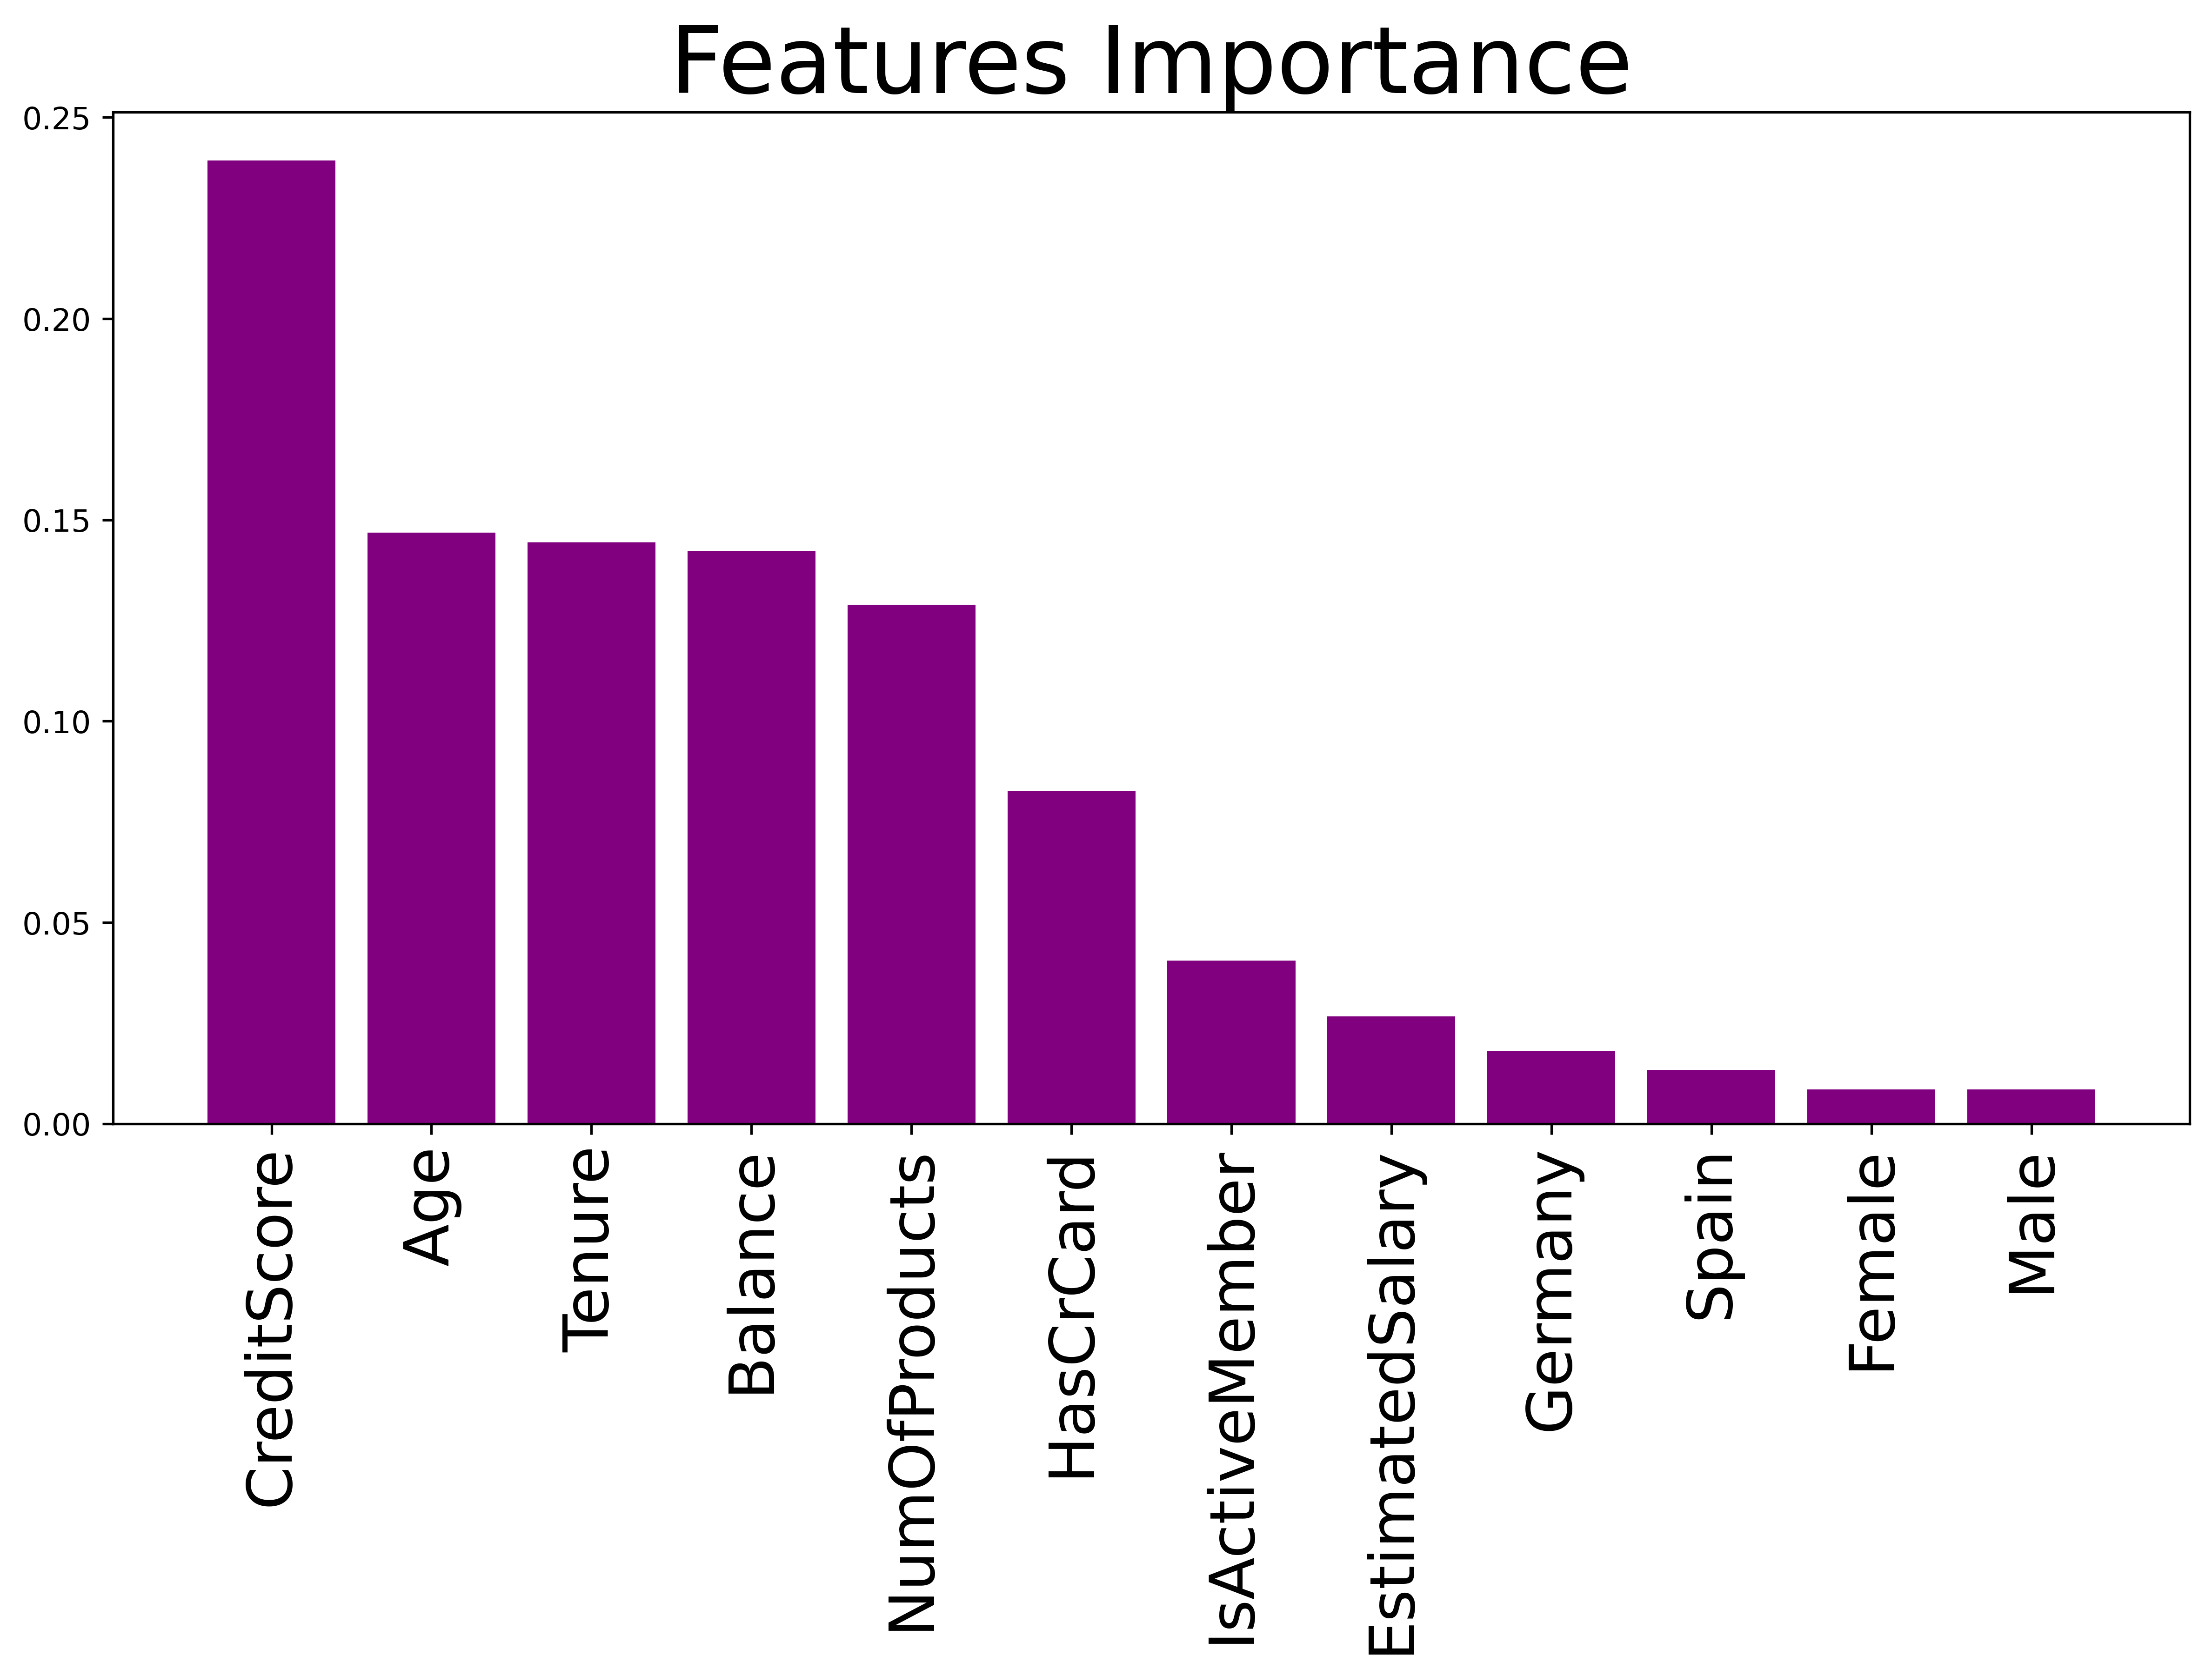

In [12]:
from sklearn.ensemble import RandomForestClassifier

# Performing training on the Random Forest model and generating the importance of the features
features_label = X.columns
forest = RandomForestClassifier (n_estimators = 10000, random_state = 0, n_jobs = -1)
forest.fit(X, Y)
importances = forest.feature_importances_
indices = np.argsort(importances)[::-1]
for i in range(X.shape[1]):
    print ("%2d) %-*s %f" % (i + 1, 30, features_label[i], importances[indices[i]]))
    
# Visualization of the Features importance
plt.figure(figsize = (12, 6), dpi = 480)
plt.title('Features Importance', fontsize = 30)
plt.bar(range(X.shape[1]), importances[indices], color = "purple", align = "center")
plt.xticks(range(X.shape[1]), features_label, rotation = 90, fontsize = 20)
plt.savefig('FeaturesImportance.png')
plt.show()